### Oxygen, Nutrients, T/S Evals in PugetSound (Becca's dataset)

In [2]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cmocean.cm as cm
import matplotlib.patches as mpatches
import scipy.stats as stat
from matplotlib.colors import LogNorm
#import plotly
from IPython.display import display, HTML
#plotly.offline.init_notebook_mode()
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))


In [3]:
# Set constant
cmap = cm.rain
period='2015-2022'
lonPS1,lonPS2,latPS1,latPS2 = (-123.2,-122.2,47.05,48.35) # Puget Sound
lonHC1,lonHC2,latHC1,latHC2 = (-123.18,-122.7,47.348,47.65) # Hood Canal
lonLC1,lonLC2,latLC1,latLC2 = (-123.1,-122.7,47.348,47.43) # Lynch Cove
lon1, lon2 = (list([lonPS1,lonHC1,lonLC1]),list([lonPS2,lonHC2,lonLC2]))
lat1, lat2 = (list([latPS1,latHC1,latLC1]),list([latPS2,latHC2,latLC2]))
tracers_obs = ['Salinity', 'Temperature', 'Oxygen_Dissolved', 'NO3', 'DIC (uM)'] 
tracers_mod = ['mod_vosaline', 'mod_votemper', 'mod_dissolved_oxygen', 'mod_nitrate', 'mod_dissolved_inorganic_carbon'] 
df,dff = (dict(),dict())
mod = ['202111','202410']
place = ['Puget Sound', 'Hood Canal', 'Lynch Cove']
#set consistent bins
Tbin,Sbin,Dbin,Nbin,Hbin = (np.linspace(0,20,100),np.linspace(25,37,100),np.linspace(0,350,100),np.linspace(0,40,100),np.linspace(0,10,100))


In [4]:
bathy = nc.Dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc','r')
mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
depth = mesh.variables['gdept_0'][:]
with xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc') as mesh:
    tmask = mesh.tmask
    mbathy = mesh.mbathy
    long = mesh.nav_lon
    latg = mesh.nav_lat
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
thalweg_HC = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/JoseTallthalwegPS.txt' 
thalweg_MB = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/JosethalwegPS.txt' 
thalweg_SoG = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_ptsHC = np.loadtxt(thalweg_HC, delimiter=' ', dtype=int)
thalweg_ptsMB = np.loadtxt(thalweg_MB, delimiter=' ', dtype=int)
thalwegs =list([thalweg_ptsMB[::-1],thalweg_ptsHC[::-1]])
depmin = list([300,170])

In [8]:
# data
pnw202111_12 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20120101_20121231.csv')
pnw202410_12 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20120101_20121231.csv')
pnw202111_13 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20130101_20131231.csv')
pnw202410_13 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20130101_20131231.csv')
pnw202111_14 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20140101_20141231.csv')
pnw202410_14 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20140101_20141231.csv')
pnw202111_15 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20150101_20151231.csv')
pnw202410_15 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20150101_20151231.csv')
pnw202111_16 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20160101_20161231.csv')
pnw202410_16 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20160101_20161231.csv')
pnw202111_17 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20170101_20171231.csv')
pnw202410_17 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20170101_20171231.csv')
pnw202111_18 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20180101_20181231.csv')
pnw202410_18 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20180101_20181231.csv')
pnw202111_19 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20190101_20191231.csv')
pnw202410_19 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20190101_20191231.csv')
pnw202111_20 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20200101_20201231.csv')
pnw202410_20 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20200101_20201231.csv')
pnw202111_21 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20210101_20211231.csv')
pnw202410_21 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20210101_20211231.csv')
pnw202111_22 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_pnw_20220101_20221231.csv')
pnw202410_22 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_pnw_20220101_20221231.csv')

pnw202111 = pd.concat([pnw202111_15, pnw202111_16, pnw202111_17, pnw202111_18, pnw202111_19, pnw202111_20, pnw202111_21, pnw202111_22
                       ], ignore_index=True)
pnw202410 = pd.concat([pnw202410_15, pnw202410_16, pnw202410_17, pnw202410_18, pnw202410_19, pnw202410_20, pnw202410_21, pnw202410_22
                       ], ignore_index=True)
#pnw202111['Salinity']=pnw202111['SA']
#pnw202111['Temperature']=pnw202111['Temp']
#pnw202111['NO3']=pnw202111['NO3 (uM)']
pnw202111

,Unnamed: 0.1,Unnamed: 0,dtUTC,Lon,Lat,Z,pressure (dbar),Temperature,Salinity,Oxygen_Dissolved,...,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_total_alkalinity,mod_dissolved_inorganic_carbon,mod_dissolved_oxygen,k
0,0,1346641,2015-01-01,-125.15,49.06,47.0,47.13425,NaN,31.626608,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
1,1,1346642,2015-01-01,-125.15,49.06,48.0,48.35840,NaN,31.619308,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,2,1346643,2015-01-01,-125.15,49.06,49.0,49.47250,NaN,31.623099,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,3,1346645,2015-01-01,-124.75,48.51,227.0,227.00000,7.691820,33.889429,NaN,...,45.953949,0.024533,0.000519,0.003179,33.887936,7.763750,2313.225098,2288.536621,96.077248,31
4,4,1346772,2015-01-02,-125.15,49.06,47.0,46.97775,NaN,31.635500,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245996,31444,2217001,2022-12-30,-125.00,48.97,6.0,6.00000,8.219548,30.784250,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
245997,31445,2217000,2022-12-30,-125.24,50.02,8.0,8.00000,8.375991,30.082221,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
245998,31446,2217009,2022-12-30,-124.77,49.49,21.0,21.00000,7.891460,29.770961,NaN,...,49.794407,1.106400,0.189468,0.147257,29.467323,6.778103,2098.438477,2029.251953,254.796967,19
245999,31447,2217010,2022-12-30,-124.77,49.49,42.0,42.00000,7.956260,29.898826,NaN,...,50.073261,1.157695,0.156737,0.129792,29.513273,6.376676,2101.466553,2029.850830,259.359467,23


/tmp/ipykernel_2847991/4057968687.py:2: UserWarning: linewidths is ignored by contourf
  ax.contourf(long, latg, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='whitesmoke')


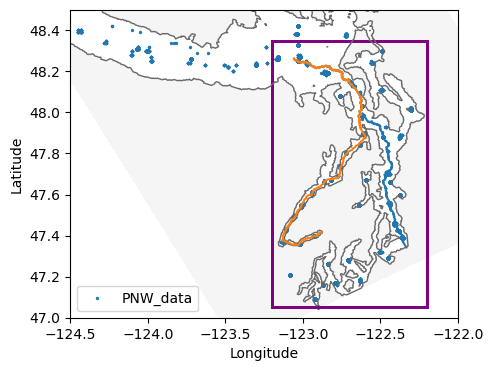

In [9]:
fig, ax = plt.subplots(1,1,figsize=(5, 4))
ax.contourf(long, latg, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(long, latg, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_ylim([47,48.5])
ax.set_xlim([-124.5,-122])
# plot the location of observations
ax.scatter(pnw202111.Lon, pnw202111.Lat, s=2, label="PNW_data")
ax.legend()
for i in range(2):
    left, bottom, width, height = (lon2[0], lat1[0], lon1[0]-lon2[0], lat2[0]-lat1[0])
    rect=mpatches.Rectangle((left,bottom),width,height, 
                        fill=False,
                        #alpha=0.1
                        color="purple",
                       linewidth=2,
                       label="Puget Sound")
    ax.plot(bathy.variables['nav_lon'][:,:][thalwegs[i][:,0],thalwegs[i][:,1]],bathy.variables['nav_lat'][:,:][thalwegs[i][:,0],thalwegs[i][:,1]])

    plt.gca().add_patch(rect)
plt.show()

In [10]:
df_21,df_24=(dict(),dict())
for i in range(len(lon1)):
    df_21[i] = pnw202111[ pnw202111['Lon'].between(lon1[i], lon2[i]) & pnw202111['Lat'].between(lat1[i], lat2[i]) & pnw202111['Z'].between(10, 200) ]
    df_24[i] = pnw202410[ pnw202410['Lon'].between(lon1[i], lon2[i]) & pnw202410['Lat'].between(lat1[i], lat2[i]) & pnw202410['Z'].between(10, 200) ]

In [11]:
def calc_stats(x, y):
    stats = {}
    MSE = np.mean((y - x)**2)
    stats['RMSE'] = np.sqrt(MSE)
    stats['bias'] = np.mean(y) - np.mean(x)
    stats['WSS'] = 1 - MSE / np.mean((abs(y - np.mean(x)) + abs(x - np.mean(x)))**2)
    
    return stats


def plot_panel(ax, x, y, lims, units):
    stats = calc_stats(x, y)

    statstext = f"RMSE = {stats['RMSE']:.3f} {units}\nbias = {stats['bias']:.3f} {units}\nWSS = {stats['WSS']:.3f}"
    
    props = dict(boxstyle='round', facecolor='w', alpha=0.9)
    c = ax.text(0.01, 0.8, statstext, bbox=props, transform=ax.transAxes, fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    return c

In [12]:
def profiles(tracer,colour,ax):
    if tracer == 'Salinity':
        t_obs = 'Salinity'
        t_mod = 'mod_vosaline'
        unit = 'Salinity (g/kg)'
        unity ='meter'
    elif tracer == 'Temperature':
        t_obs = 'Temperature'
        t_mod = 'mod_votemper'
        unit = 'Temperature (°C)'
        unity ='meter'
    elif tracer == 'NO3':
        t_obs = 'NO3'
        t_mod = 'mod_nitrate'
        unit = 'NO3 (uM)'
        unity ='meter'
    elif tracer == 'NH4':
        t_obs = 'NH4'
        t_mod = 'mod_ammonium'
        unit = 'NH4-uM'
        unity ='meter'
    elif tracer == 'DO':
        t_obs = 'Oxygen_Dissolved'
        t_mod = 'mod_dissolved_oxygen'
        unit = 'DO (uM)'
        unity ='meter'
    elif tracer == 'DIC':
        t_obs = 'DIC (uM)'
        t_mod = 'mod_dissolved_inorganic_carbon'
        unit = 'DIC (uM)'
        unity ='meter'
    avg_obs, avg_21, avg_24, binsa, bins, binsa =(dict(),dict(),dict(),dict(),dict(),dict())
    for i in range(len(lon1)):
        avg_obs[i], binsa[i], _ = stat.binned_statistic(-df_21[i]['Z'][(np.isfinite(df_21[i][t_obs]))],df_21[i][t_obs][(np.isfinite(df_21[i][t_obs]))],statistic='mean',bins=40)
        avg_21[i], bins[i], _ = stat.binned_statistic(-df_21[i]['Z'][(np.isfinite(df_21[i][t_mod]))],df_21[i][t_mod][(np.isfinite(df_21[i][t_mod]))],statistic='mean',bins=40)
        avg_24[i], binsa[i], _ = stat.binned_statistic(-df_24[i]['Z'][(np.isfinite(df_24[i][t_mod]))],df_24[i][t_mod][(np.isfinite(df_24[i][t_mod]))],statistic='mean',bins=40)

    ax.plot(avg_obs[0], binsa[0][:-1], lw=2,label='obs')
    ax.plot(avg_21[0], bins[0][:-1], lw=2,label='202111')
    ax.plot(avg_24[0], binsa[0][:-1], lw=2,label='202410')
    ax.set_xlabel(unit)
    #ax.set_ylabel(unity)

    title = tracer
    #ax.set_title(title)

2015-2022


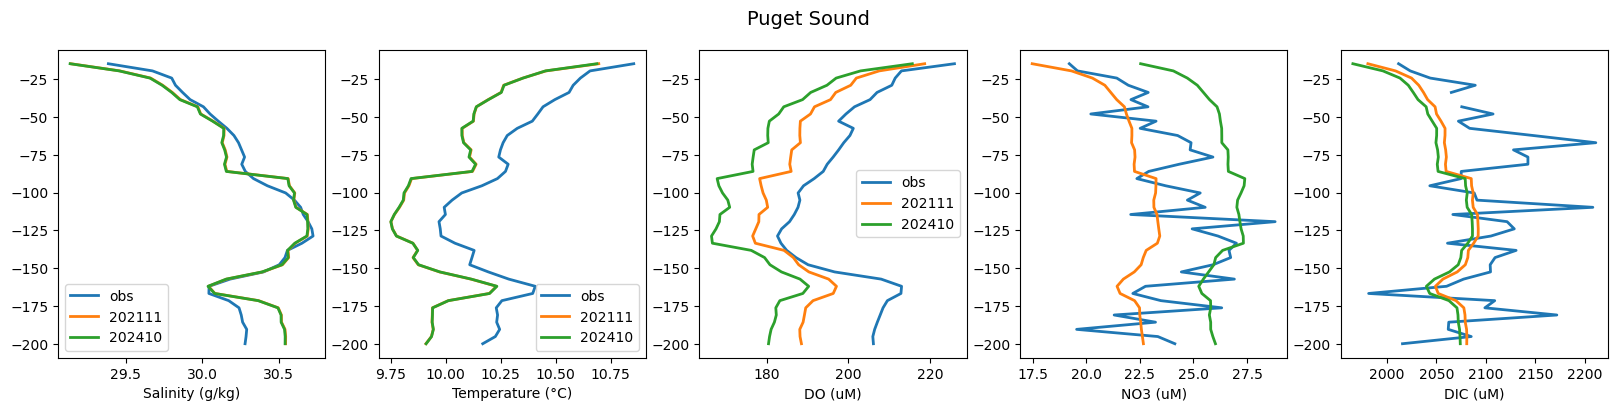

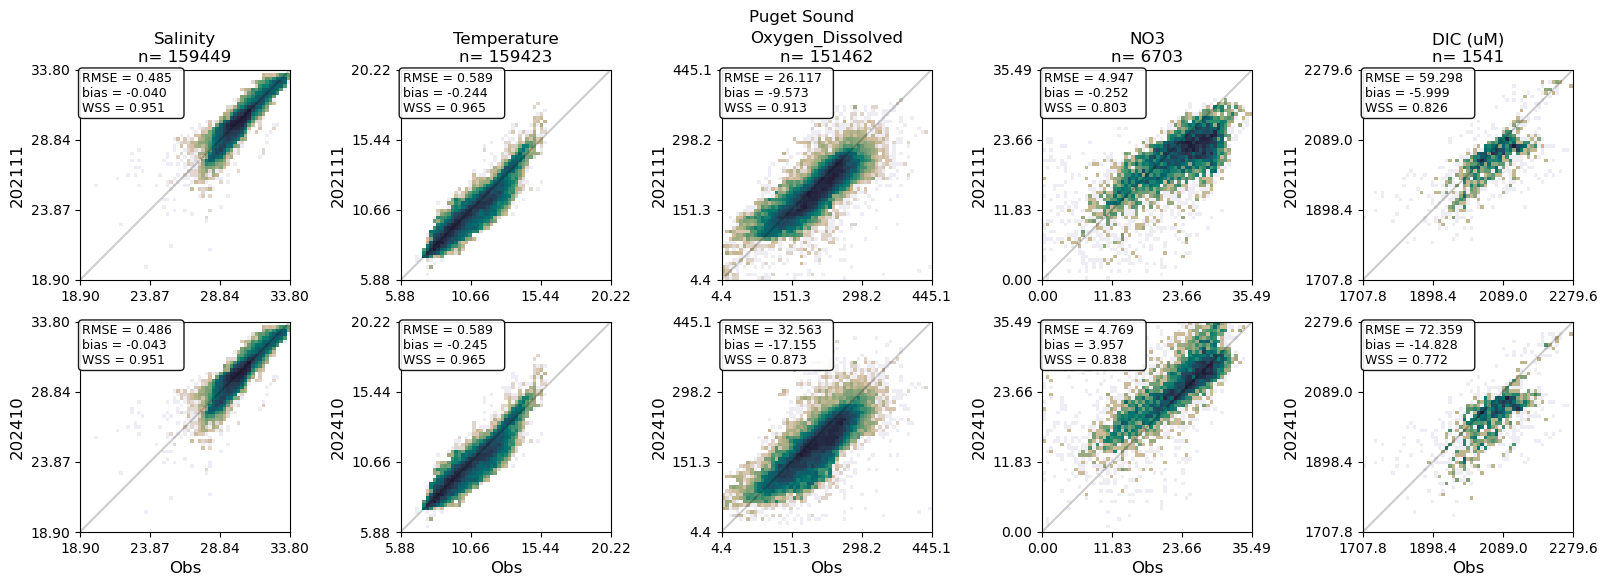

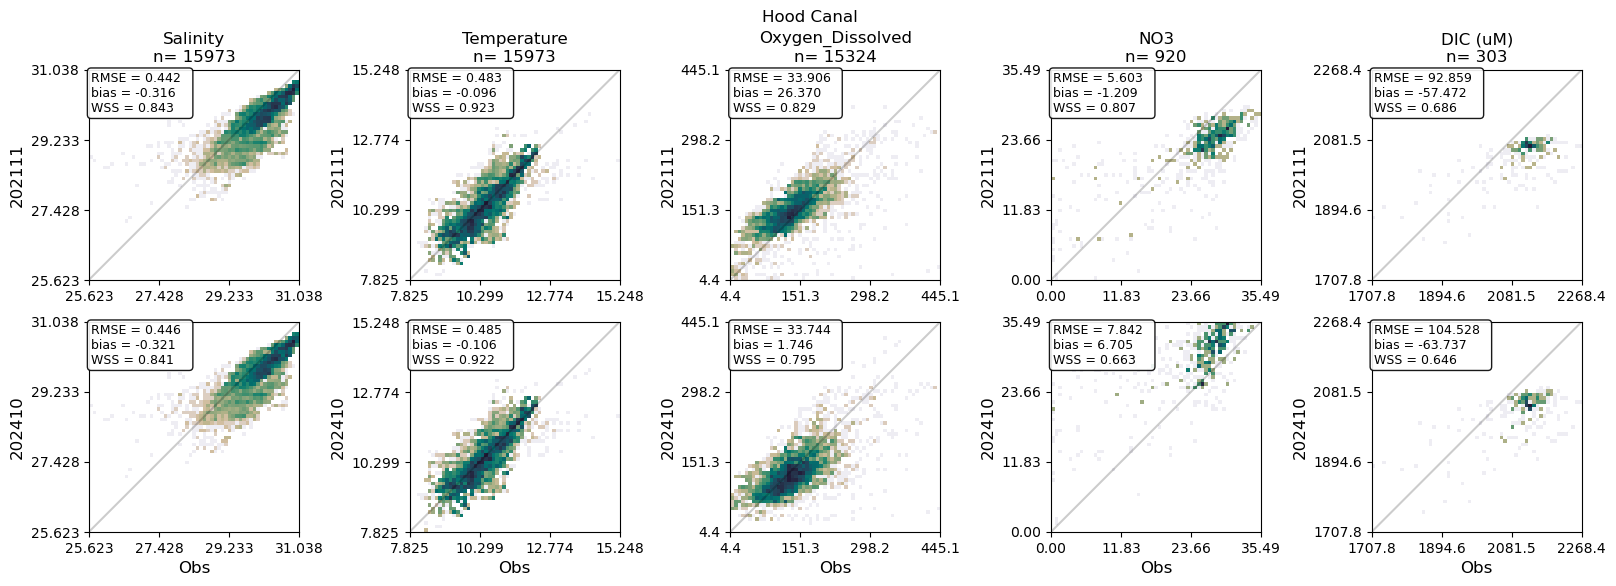

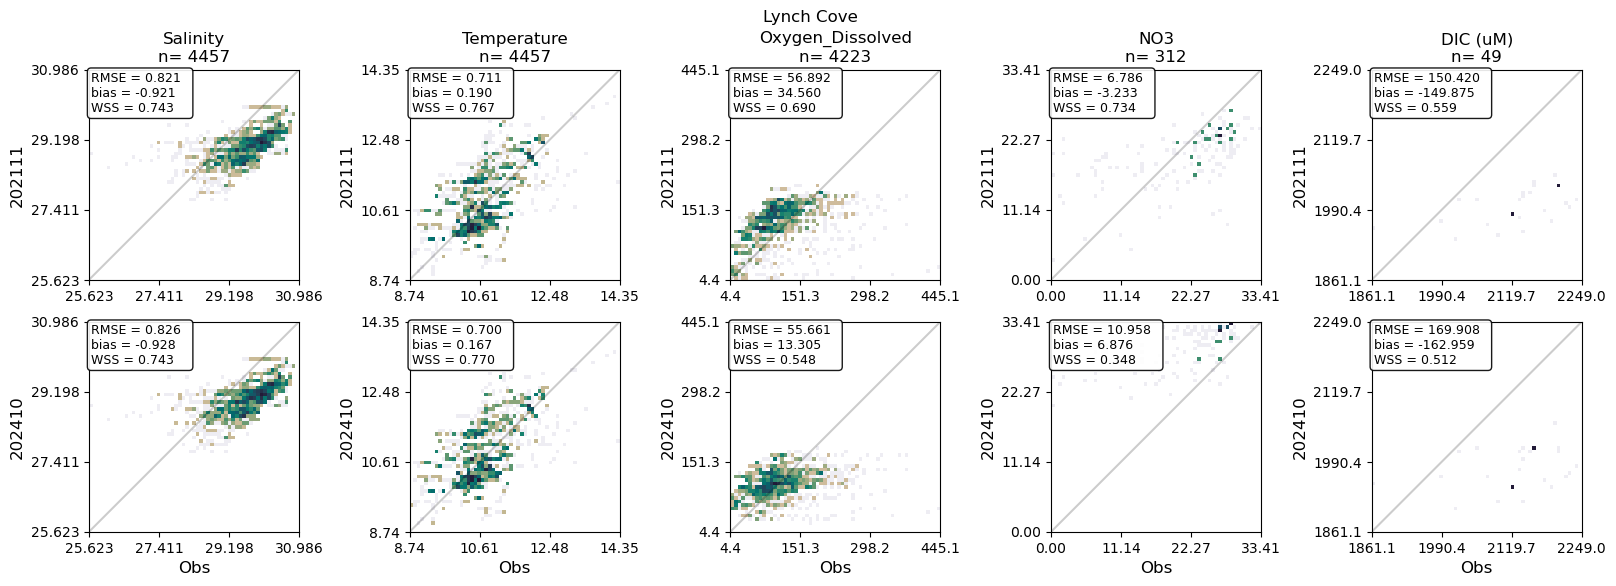

In [13]:
print(period)

# plot profiles
fig, ax = plt.subplots(1, 5, figsize=(20,4))
fig.suptitle('Puget Sound',fontsize=14)
profiles('Salinity','k',ax[0])
profiles('Temperature','k',ax[1])
profiles('DO','k',ax[2])
profiles('NO3','k',ax[3])
profiles('DIC','k',ax[4])
#profiles('NH4','k',ax[4])
ax[0].legend()
ax[1].legend()
ax[2].legend()
######################################
for k in range(len(lon1)):
    fig, axs = plt.subplots(len(mod), len(tracers_obs), figsize = (4*len(tracers_obs), 6)) 
    dff = list([df_21[k],df_24[k]])
    for i in range(len(tracers_obs)):
        for j in range(len(mod)):
            df=dff[j]
            vmin, vmax = np.min(df[tracers_obs[i]]), np.max(df[tracers_obs[i]])
            bin = np.linspace(vmin,vmax,60)

            axs[j,i].plot((vmin,vmax),(vmin,vmax),'k-',alpha=.2)

            iiS=(~np.isnan(df[tracers_obs[i]]))&(~np.isnan(df[tracers_mod[i]]))

            counts, xedges, yedges, m2=axs[j,i].hist2d(df.loc[iiS,[tracers_obs[i]]].values.flatten(),
                                        df.loc[iiS,[tracers_mod[i]]].values.flatten(),bins=bin,norm=LogNorm(),cmap=cmap)

            ntick=np.linspace(vmin, vmax, 4)
            axs[j,i].set_xticks(ntick)
            axs[j,i].set_yticks(ntick)
        
            axs[j,i].set_aspect(1, adjustable='box')
            axs[j,i].set_ylabel(f'{mod[j]}',fontsize=12)
            axs[1,i].set_xlabel('Obs',fontsize=12)

            title = tracers_obs[i]+'\nn= '+str(np.count_nonzero(~np.isnan(df[tracers_obs[i]])))
            axs[0,i].set_title(title,fontsize=12)

        # plot the stats pannel
            plot_panel(axs[j,i], df[tracers_obs[i]], df[tracers_mod[i]], (vmin,vmax), ' ')
            fig.suptitle(f'{place[k]}')



